In [5]:
import numpy as np
from matplotlib import pyplot as plt
import nibabel as nb
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt
from glob import glob
import tifffile as tiff
from tqdm import tqdm
import sys
import os
from glob import glob
sys.path.append('../')

# from slice_structure_identification_functions import compute_signed_distance_weight as compute_signed_distance_weight
# from slice_structure_identification_functions import compute_signed_distance_weight_filled as compute_signed_distance_weight_filled
from slice_registration_functions import apply_coordinate_mapping_2d, downsample_image

398it [00:06, 59.63it/s]


Processed 398 slices successfully.
Processed 398 slices successfully.


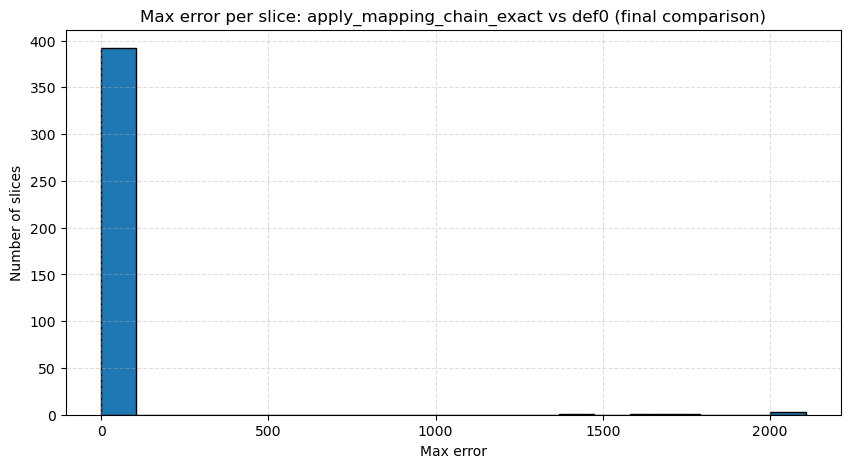

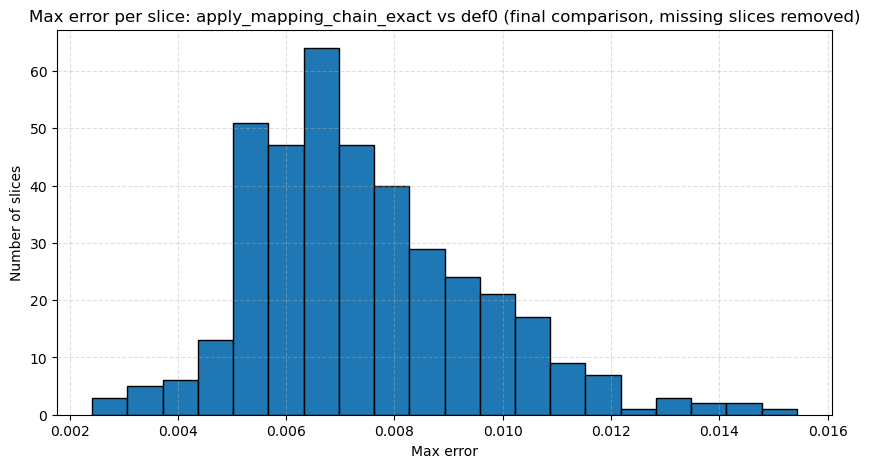

In [ ]:
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0 #just for plotting, the bad slices are missing/bad data and very far
for name_idx, orig_fname in tqdm(enumerate(orig_fnames)):
    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]

    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    # print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    # comp_exact = apply_mapping_chain_exact(src, [m1_, m2_, m3_, m4_, m5_, m6_, m7_, m8_, m9_]).get_fdata()

    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

plt.figure(figsize=(10, 5))
plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()




In [9]:
slice_pathroot_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'

# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'


label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
final_space_labels = {}
final_space_labels['img'] =[]
final_space_labels['fname_header'] =[]
final_space_labels['final_reg_space_def0'] = []
for name_idx, orig_fname in enumerate(orig_fnames):
    
    # labeled_maskos.path.basename(PC_files[0].split('_mask_')[0])
    # labeled_mask 

    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]
    fname_header = base_slice.split('__')[0]
    labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
    if len(labeled_mask) == 0:
        # print(f"No labeled mask found for {slice_name}")
        continue
    elif len(labeled_mask) > 1:
        # print(f"Multiple labeled masks found for {slice_name}: {labeled_mask}")
        continue        
    
        
    labeled_mask_fname = labeled_mask[0]
    if os.path.exists(labeled_mask_fname):
        print(f"Found labeled mask for {slice_name}: {labeled_mask_fname}")
    
    labeled_mask = tiff.imread(labeled_mask_fname).astype(bool).astype(np.uint8) # read and convert to bin
    _ds_label_cnt = downsample_image(labeled_mask, 40, pad_value=-1*0) #now counts per pixel
    
    



    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    label_cnt_img = nb.Nifti1Image(_ds_label_cnt, affine=src.affine, header=src.header)

    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    labeled_seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        label_cnt_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)

    final_space_labels['img'].append(labeled_seq)
    final_space_labels['fname_header'].append(fname_header)
    final_space_labels['final_reg_space_def0'].append(nb.load(final_comparison_img))
    break
    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()




Found labeled mask for zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif
zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz
Processed 0 slices successfully.
Processed 0 slices successfully.


In [37]:
def crop_to_nonzero_with_padding(img, pad=1):
    # find nonzero locations
    nz = np.argwhere(img != 0)
    if nz.size == 0:
        return img  # all-zero case, or return np.zeros((0,0))
    r0, c0 = nz.min(axis=0)
    r1, c1 = nz.max(axis=0)
    # pad with one pixel, clipped to image boundary
    r0 = max(0, r0 - pad)
    c0 = max(0, c0 - pad)
    r1 = min(img.shape[0]-1, r1 + pad)
    c1 = min(img.shape[1]-1, c1 + pad)
    return img[r0:r1+1, c0:c1+1], (r0, r1, c0, c1)

(2178, 2622)
(63158, 76025)
[28.99816345 28.99504195]
[29. 29.]


<Figure size 1500x500 with 0 Axes>

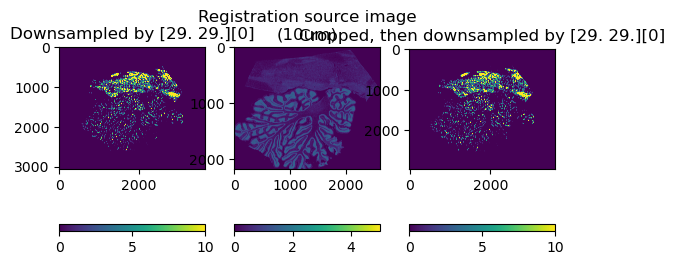

In [ ]:
reg_orig_data = tiff.imread('/data/neuralabc/neuralabc_volunteers/macaque/testProject2/results_cell_counts/_Image_03_-_20x_cellCount_29_downsample_10p002um_pix.tif')
print(reg_orig_data.shape)
mask_orig_data = labeled_mask.copy()
print(mask_orig_data.shape)
print(np.array(mask_orig_data.shape)/np.array(reg_orig_data.shape))
scales = np.ceil(np.array(mask_orig_data.shape)/np.array(reg_orig_data.shape))
print(scales)
ds10um = downsample_image(labeled_mask, int(scales[0]), pad_value=-1*0) #now counts per pixel

labeled_mask_cropped = crop_to_nonzero_with_padding(labeled_mask)[0]
ds10um_cropped = downsample_image(labeled_mask_cropped, int(scales[0]), pad_value=-1*0) #now counts per pixel



<Figure size 1500x500 with 0 Axes>

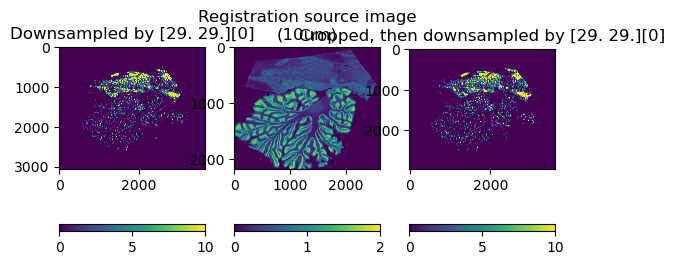

In [40]:

plt.figure(figsize=(15, 5))
plt.subplots(1,3)
plt.subplot(1,3,1)
plt.imshow(ds10um, cmap='viridis',vmax=10)
plt.title(f'Downsampled by {scales}[0]')
plt.colorbar(orientation='horizontal')
plt.subplot(1,3,2)
plt.imshow(reg_orig_data, cmap='viridis',vmax=2)
plt.title('Registration source image\n(10um)')
plt.colorbar(orientation='horizontal')
plt.subplot(1,3,3)
plt.imshow(ds10um_cropped, cmap='viridis',vmax=10)
plt.title(f'Cropped, then downsampled by {scales}[0]')
plt.colorbar(orientation='horizontal')

(63158, 76025)
(3158, 3802)
(77, 103)
(111, 134)


<Figure size 1000x500 with 0 Axes>

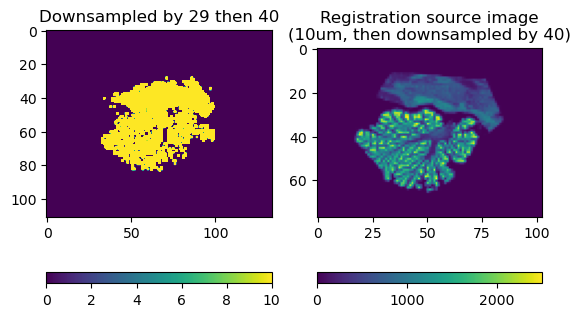

In [ ]:
print(labeled_mask.shape)
ds10 = downsample_image(labeled_mask, 29, pad_value=-1*0) #now counts per pixel
print(ds10.shape)
print(nb.load(source_img).shape)

ds10_40 = downsample_image(ds10, 40, pad_value=-1*0) #now counts per pixel
print(ds10_40.shape)
plt.figure(figsize=(10, 5))
plt.subplots(1,2)
plt.subplot(1,2,1)
plt.imshow(ds10_40, cmap='viridis',vmax=10)
plt.title('Downsampled by 29 then 40')
plt.colorbar(orientation='horizontal')
plt.subplot(1,2,2)
plt.imshow(src.get_fdata(), cmap='viridis')
plt.title('Registration source image\n(10um, then downsampled by 40)')
plt.colorbar(orientation='horizontal')

In [8]:
_ds = downsample_image(labeled_mask, 40, pad_value=-1*0) #now counts per pixel
print(_ds.shape)
print(src.shape)

(2211, 2661)
(77, 103)


In [ ]:
_t = np.zeros_like(src.get_fdata())
print(_t.shape)
print(type(_t[0,0]))
print(src.shape)
_d = label_cnt_img.get_fdata()
_t = _d[1000:1000+src.shape[0],1000:1000+src.shape[1]]
print(_t.shape)
print(type(_t[0,0]))
print(src.shape)
# _t[20,20] = 200
_t_img = nb.Nifti1Image(_t, affine=src.affine, header=src.header)
print(_t_img.shape)
labeled_seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        _t_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)


(77, 103)
<class 'numpy.float64'>
(77, 103)
(77, 103)
<class 'numpy.float64'>
(77, 103)
(77, 103)


AttributeError: 'numpy.ndarray' object has no attribute 'get_fdata'

In [51]:
src.shape

(77, 103)

In [53]:
print(m1_.shape)
_t_img.shape
print(_t_img.get_fdata().shape)

(78, 110, 2)
(77, 103)


In [54]:
print(_t_img.get_fdata().sum())
labeled_seq.get_fdata().sum()

25042.0


23862.21450715268

In [5]:
\
current_shape = labeled_mask.shape
scale_factors = 1/(np.array(target_shape) / np.array(current_shape))

print(f"Current shape: {current_shape}")
print(f"Scale factors: {scale_factors}")


NameError: name 'target_shape' is not defined